# Adapter Evaluation

Generate lyrics from trained adapters, classify with RoBERTa, and compare against baselines.

In [1]:
import json

import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
matplotlib.rcParams["pdf.fonttype"] = 42

from config import adapter_registry, Adapter, ARTISTS, RESULTS_DIR

# Display-only notebook: it reads cached results, no model is loaded here.
# Generate the cache first with:  uv run python evaluate.py

## Adapter results

Loaded from the cache written by `evaluate.py`. Run `uv run python evaluate.py` first.

In [2]:
# Load per-adapter results cached by evaluate.py (results/adapters/<artist>/<variant>.json).
# Keyed by display label; the Adapter object is re-attached from the registry.
# A STALE notice means the adapter was retrained after its cache was written.
CACHE_DIR = RESULTS_DIR / "adapters"


def _weights_mtime(path):
    return max(f.stat().st_mtime for f in path.rglob("*") if f.is_file())


all_results = {}

for a in adapter_registry():
    cache_file = CACHE_DIR / a.result_relpath
    if not cache_file.exists():
        print(f"skip {a.label}: not evaluated -- run `uv run python evaluate.py`")
        continue

    hit = json.load(open(cache_file))
    if a.path.exists() and hit.get("mtime") != _weights_mtime(a.path):
        print(f"STALE {a.label}: weights newer than cache -- re-run evaluate.py")

    df = pd.DataFrame(hit["df"])
    all_results[a.label] = {"adapter": a, "target": a.artist,
                            "samples": hit["samples"], "df": df}
    print(f"loaded {a.label}: mean {df[a.artist].mean():.4f}")

loaded Gojira LoRA r=8: mean 0.9768
loaded Gojira DoRA r=8: mean 0.8715
loaded Tool LoRA r=8: mean 0.6033
loaded Tool DoRA r=8: mean 0.7635
loaded Death LoRA r=8: mean 0.9940
loaded Death DoRA r=8: mean 0.9935
loaded Meshuggah LoRA r=8: mean 0.6273
loaded Meshuggah DoRA r=8: mean 0.7920
loaded Opeth LoRA r=8: mean 0.9919
loaded Opeth DoRA r=8: mean 0.9925
loaded Gojira LoRA r=4: mean 0.8752
loaded Gojira LoRA r=16: mean 0.8451
loaded Gojira LoRA r=8 SW: mean 0.5271


## Baselines (from 04_baselines.ipynb)

Read from the per-(artist, method) caches in `results/baselines/<artist>/` (written by `04`) so the numbers never drift from a hardcoded copy. Run `04` first.

In [3]:
# Baseline rows from the per-(artist, method) caches written by 04_baselines.
BASELINES_DIR = RESULTS_DIR / "baselines"
_METHOD_LABEL = {"zero_shot": "Zero-shot", "few_shot": "Few-shot"}

rows = []
for artist in ARTISTS:
    slug = artist.lower().replace(" ", "_")
    for method, mlabel in _METHOD_LABEL.items():
        cache_file = BASELINES_DIR / slug / f"{method}.json"
        if not cache_file.exists():
            continue
        df = pd.DataFrame(json.load(open(cache_file))["df"])
        rows.append({"Method": f"{artist} {mlabel}", "Artist": artist,
                     "Target Attr. (mean)": df[artist].mean(),
                     "Target Attr. (std)": df[artist].std()})

if not rows:
    print(f"note: no baseline caches in {BASELINES_DIR} -- run 04_baselines first; showing adapters only\n")

for label, data in all_results.items():
    target = data["target"]
    rows.append({"Method": label, "Artist": target,
                 "Target Attr. (mean)": data["df"][target].mean(),
                 "Target Attr. (std)": data["df"][target].std()})

summary = pd.DataFrame(rows)
summary["Target Attr. (mean)"] = summary["Target Attr. (mean)"].round(4)
summary["Target Attr. (std)"] = summary["Target Attr. (std)"].round(4)
print(summary.to_string(index=False))

             Method    Artist  Target Attr. (mean)  Target Attr. (std)
   Gojira Zero-shot    Gojira               0.0076              0.0061
    Gojira Few-shot    Gojira               0.1412              0.2999
     Tool Zero-shot      Tool               0.9571              0.0364
      Tool Few-shot      Tool               0.8842              0.1902
    Death Zero-shot     Death               0.0132              0.0176
     Death Few-shot     Death               0.0109              0.0075
Meshuggah Zero-shot Meshuggah               0.0080              0.0037
 Meshuggah Few-shot Meshuggah               0.0170              0.0228
    Opeth Zero-shot     Opeth               0.0024              0.0013
     Opeth Few-shot     Opeth               0.0035              0.0019
    Gojira LoRA r=8    Gojira               0.9768              0.0402
    Gojira DoRA r=8    Gojira               0.8715              0.2863
      Tool LoRA r=8      Tool               0.6033              0.4324
      

## Plots

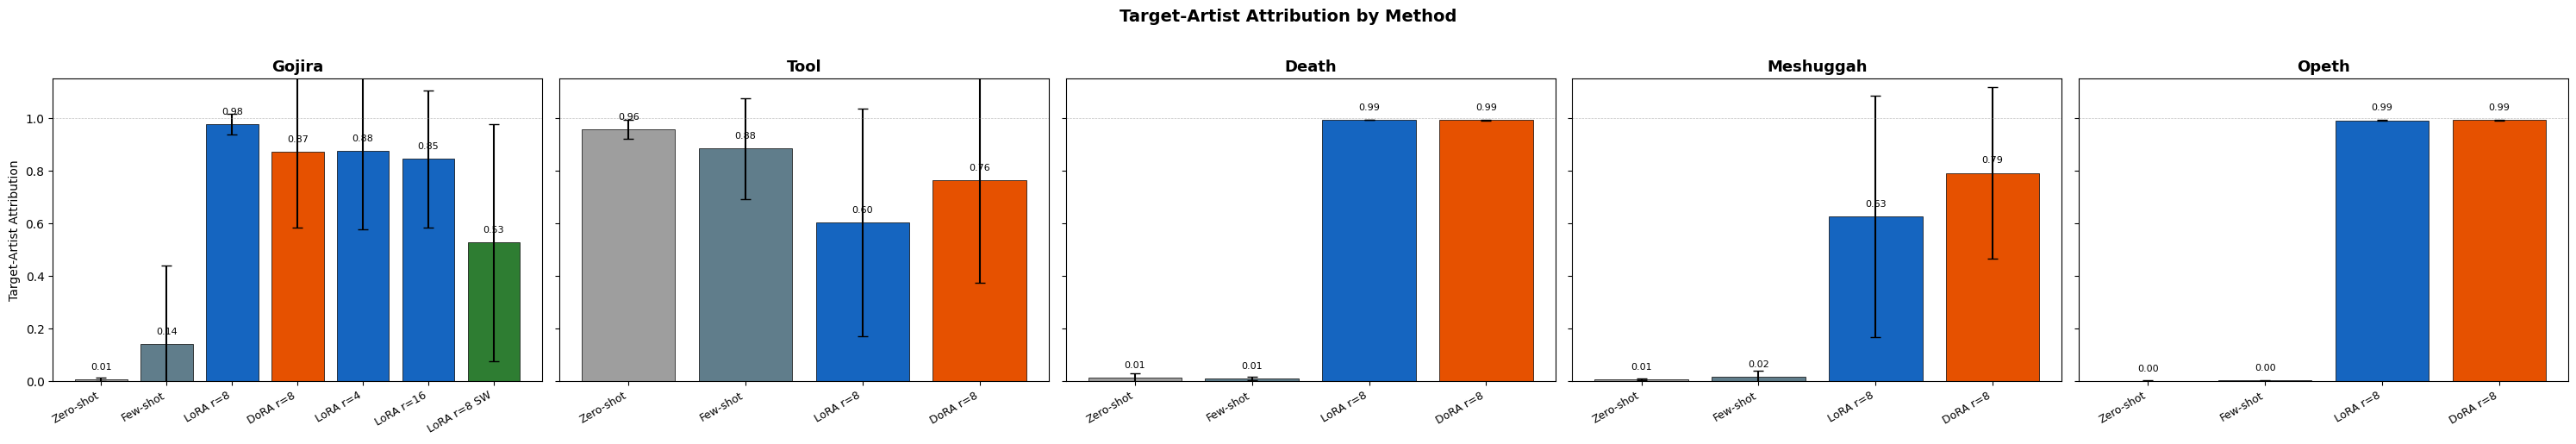

In [4]:
# One panel per artist that appears in the summary (baseline or adapter).
artists_present = [a for a in ARTISTS if (summary["Artist"] == a).any()]
n = len(artists_present)
fig, axes = plt.subplots(1, n, figsize=(6 * n, 5), sharey=True)
if n == 1:
    axes = [axes]

for ax, artist in zip(axes, artists_present):
    artist_rows = summary[summary["Artist"] == artist].copy()
    artist_rows["short"] = artist_rows["Method"].str.replace(f"{artist} ", "", regex=False)
    means = artist_rows["Target Attr. (mean)"].values
    stds = artist_rows["Target Attr. (std)"].values
    labels_plot = artist_rows["short"].values
    x = np.arange(len(labels_plot))

    colors = []
    for label in labels_plot:
        if "Zero" in label:
            colors.append("#9e9e9e")
        elif "Few" in label:
            colors.append("#607d8b")
        elif "SW" in label:
            colors.append("#2e7d32")
        elif "DoRA" in label:
            colors.append("#e65100")
        else:
            colors.append("#1565c0")

    bars = ax.bar(x, means, yerr=stds, capsize=4, color=colors, edgecolor="black", linewidth=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels_plot, rotation=30, ha="right", fontsize=9)
    ax.set_title(f"{artist}", fontsize=13, fontweight="bold")
    ax.set_ylim(0, 1.15)
    ax.axhline(y=1.0, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

    for bar, m in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
                f"{m:.2f}", ha="center", va="bottom", fontsize=8)

axes[0].set_ylabel("Target-Artist Attribution")
plt.suptitle("Target-Artist Attribution by Method", fontsize=14, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig("../report/figures/method_comparison.pdf", bbox_inches="tight", dpi=300)
plt.show()

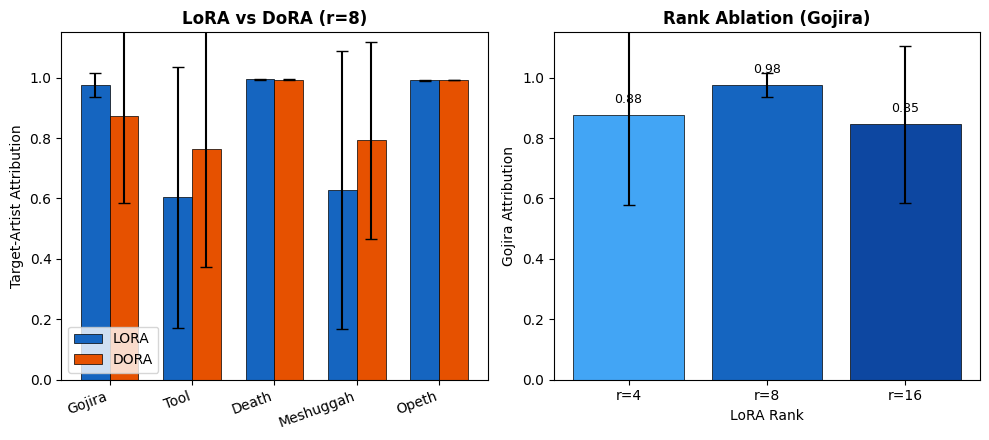

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4.5))

# LoRA vs DoRA: every artist that has BOTH a lora r8 and dora r8 result.
lora_dora_artists = [
    a for a in ARTISTS
    if Adapter(a, "lora", 8).label in all_results and Adapter(a, "dora", 8).label in all_results
]

ax = axes[0]
x = np.arange(len(lora_dora_artists))
w = 0.35
for i, (kind, color) in enumerate([("lora", "#1565c0"), ("dora", "#e65100")]):
    means, stds = [], []
    for artist in lora_dora_artists:
        d = all_results[Adapter(artist, kind, 8).label]
        means.append(d["df"][d["target"]].mean())
        stds.append(d["df"][d["target"]].std())
    ax.bar(x + i * w, means, w, yerr=stds, capsize=4, label=kind.upper(),
           color=color, edgecolor="black", linewidth=0.5)
ax.set_xticks(x + w / 2)
ax.set_xticklabels(lora_dora_artists, rotation=20, ha="right")
ax.set_ylabel("Target-Artist Attribution")
ax.set_title("LoRA vs DoRA (r=8)", fontweight="bold")
ax.legend()
ax.set_ylim(0, 1.15)

# Rank ablation (Gojira): whichever of r=4/8/16 are present.
ax = axes[1]
rank_specs = [s for s in (Adapter("Gojira", "lora", r) for r in (4, 8, 16)) if s.label in all_results]
rank_labels = [f"r={s.rank}" for s in rank_specs]
rank_means = [all_results[s.label]["df"]["Gojira"].mean() for s in rank_specs]
rank_stds = [all_results[s.label]["df"]["Gojira"].std() for s in rank_specs]
bars = ax.bar(rank_labels, rank_means, yerr=rank_stds, capsize=4,
              color=["#42a5f5", "#1565c0", "#0d47a1"][:len(rank_specs)],
              edgecolor="black", linewidth=0.5)
for bar, m in zip(bars, rank_means):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.03,
            f"{m:.2f}", ha="center", va="bottom", fontsize=9)
ax.set_ylabel("Gojira Attribution")
ax.set_xlabel("LoRA Rank")
ax.set_title("Rank Ablation (Gojira)", fontweight="bold")
ax.set_ylim(0, 1.15)

plt.tight_layout()
plt.savefig("../report/figures/ablation.pdf", bbox_inches="tight", dpi=300)
plt.show()

## Sample Lyrics

Best sample per adapter (highest target-artist attribution).

In [6]:
for name, data in all_results.items():
    target = data["target"]
    best_idx = data["df"][target].idxmax()
    score = data["df"].loc[best_idx, target]
    text = data["samples"][best_idx]
    print(f"{'='*60}")
    print(f"{name} — best sample (attribution: {score:.3f})")
    print(f"{'='*60}")
    print(text[:800])
    print("...\n" if len(text) > 800 else "\n")

Gojira LoRA r=8 — best sample (attribution: 0.991)
This is the story of my life
And how I overcome all the pain
I'm walking away from what kills me
One step at a time, getting stronger
All along the way to salvation
All those trials and tears are fading away
But now I find a shelter in myself
My inner light has come back to life


These walls cannot hold me
The strength inside is growing, rising up
It feels so good to let it go now
Let it flow through me for all time
You can tell by the look on my face
That you're wasting your time with these lies
It feels so good to let it go now
Let it flow through me for all time


Now I see my destiny revealed
In dreams there's no one else but me
No one can ever take this pride away
From out of sight I run
Running non-stop through time and space
Flashes flying straight in the eyes
Of all those who dare
...

Gojira DoRA r=8 — best sample (attribution: 0.991)
And now I feel like a lion
I grow and grow stronger
But the cold is inside me
Like an eagle,